In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.274539e-12,-9.512736e-13,-4.398678e-13,-1.029671e-13,-3.838944e-13,7.529013e-13,-3.405412e-14,-1.660106e-13,1.027627e-13,...,-4.078958e-13,-9.849381e-13,-1.763859e-13,4.203004e-13,1.603967e-13,2.986665e-13,2.308042e-12,-2.239082e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found!")

Missing values:
Series([], dtype: int64)

No missing values found!


In [8]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 1081


In [9]:
class_counts = df["Class"].value_counts()

print("Class Distribution:")
print(class_counts)

print("\nPercentage Distribution:")
print(df["Class"].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Visualize class imbalance


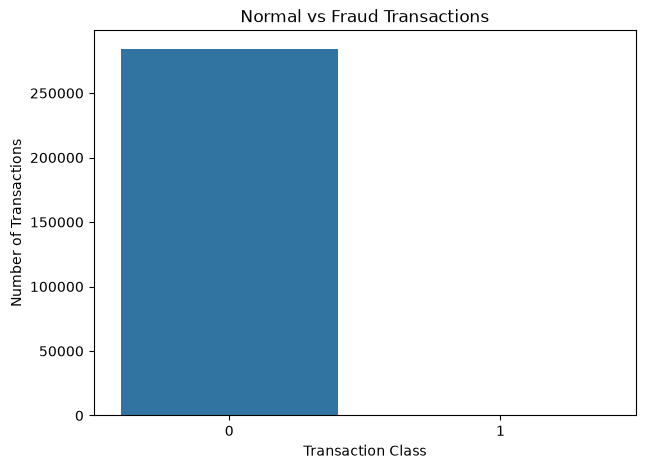

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

Fraud percentage


In [11]:
fraud_count = df["Class"].sum()
total_count = len(df)

fraud_percentage = (fraud_count / total_count) * 100

print(f"Total transactions: {total_count:,}")
print(f"Fraud transactions: {fraud_count:,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")

Total transactions: 284,807
Fraud transactions: 492
Fraud percentage: 0.1727%


Transaction amount distribution

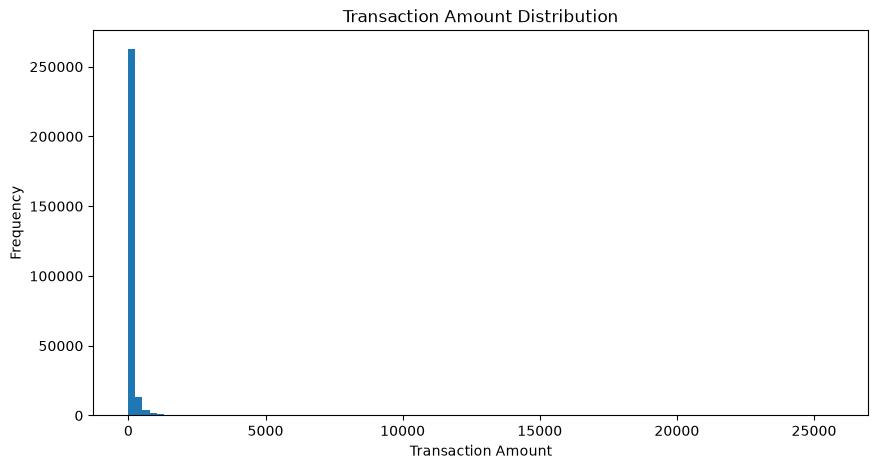

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(df["Amount"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

 Normal vs fraud amount

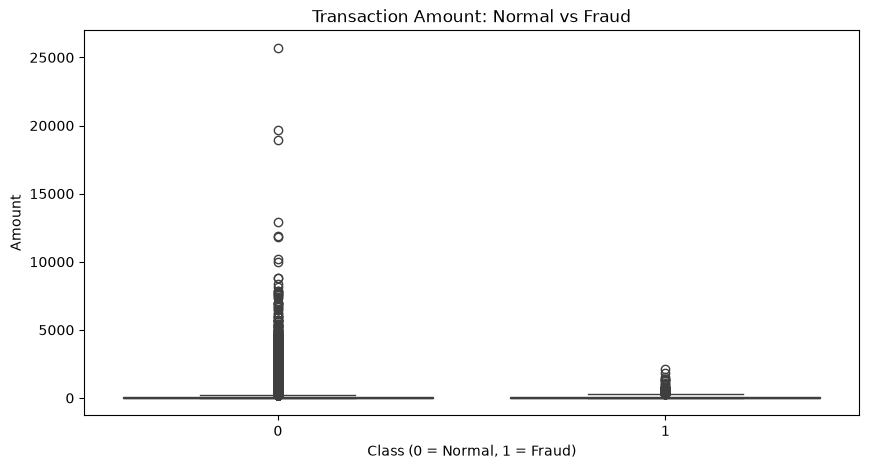

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

Time distribution

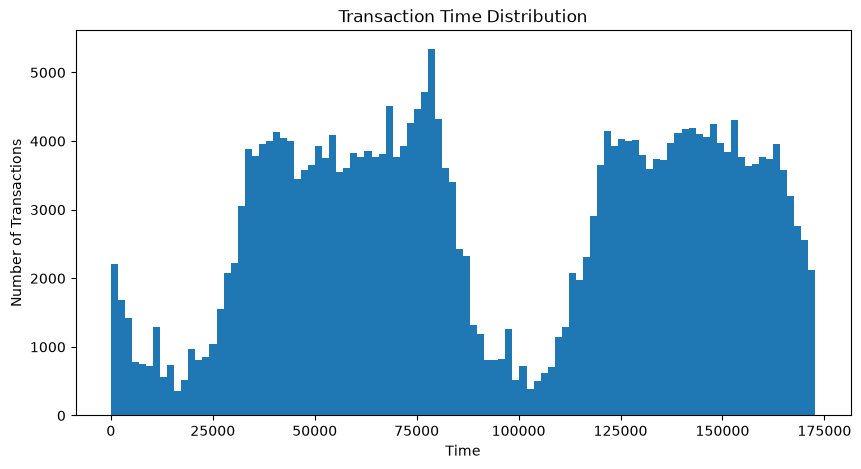

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(df["Time"], bins=100)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

In [15]:
correlation = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print(correlation)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


Separate features and target

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


Train/test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


Scale Time and Amount

In [18]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Scaling completed!")

Scaling completed!


Create Isolation Forest

In [ ]:
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.001727,
    random_state=42,
    n_jobs=-1
)

print("Isolation Forest created!")

Train the model

In [21]:
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.001727,
    random_state=42,
    n_jobs=-1
)


print("Training Isolation Forest...")

isolation_model.fit(X_train)

print("Training completed!")

Training Isolation Forest...
Training completed!


Generate predictions

In [22]:
predictions = isolation_model.predict(X_test)

print("Raw predictions:")
print(np.unique(predictions, return_counts=True))

Raw predictions:
(array([-1,  1]), array([  107, 56855]))


Convert predictions

In [23]:
y_pred = np.where(predictions == -1, 1, 0)

print("Converted predictions:")
print(pd.Series(y_pred).value_counts())

Converted predictions:
0    56855
1      107
Name: count, dtype: int64


Confusion matrix

In [24]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56787    77]
 [   68    30]]


Display confusion matrix visually

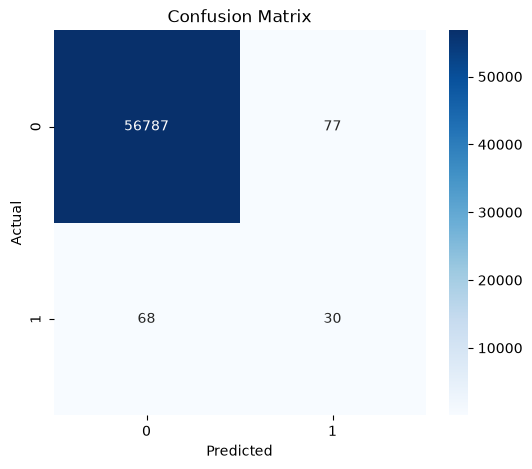

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Precision, Recall and F1

In [26]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.2804
Recall:    0.3061
F1 Score:  0.2927


Precision: 0.2804
Recall:    0.3061
F1 Score:  0.2927


Classification report

In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.28      0.31      0.29        98

    accuracy                           1.00     56962
   macro avg       0.64      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962



In [29]:
anomaly_scores = isolation_model.decision_function(X_test)

print("First 10 anomaly scores:")
print(anomaly_scores[:10])

First 10 anomaly scores:
[0.25281579 0.16579677 0.12467368 0.2969003  0.19499593 0.28230423
 0.23724656 0.2834137  0.27742535 0.2719669 ]


Add predictions to test data

In [30]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred
results["AnomalyScore"] = anomaly_scores

results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,AnomalyScore
263020,1.387182,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.259954,0,0,0.252816
11378,-1.580138,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.304426,0,0,0.165797
147283,-0.138120,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.048286,0,0,0.124674
219439,0.986536,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.347741,0,0,0.296900
36939,-1.182272,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.345707,0,0,0.194996


Compare actual fraud vs detected fraud

In [31]:
actual_fraud = (y_test == 1).sum()
detected_fraud = ((y_test == 1) & (y_pred == 1)).sum()

print("Actual fraud transactions:", actual_fraud)
print("Fraud transactions detected:", detected_fraud)
print(
    "Detection rate:",
    f"{(detected_fraud / actual_fraud) * 100:.2f}%"
)

Actual fraud transactions: 98
Fraud transactions detected: 30
Detection rate: 30.61%


models/

In [32]:
joblib.dump(
    isolation_model,
    "../models/isolation_forest.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
